# Edge detection

In [1]:
#%%
import matplotlib.pyplot as plt
import numpy as np
import cv2

file_name = "../images/lenna.png"
src = cv2.imread(file_name, 0).astype(np.float32)

mask_size = 5
mask = np.zeros((mask_size, mask_size), dtype=np.float32)


prewit = {'h': mask.copy(),'v': mask.copy()}
prewit['h'][0] = -1
prewit['h'][mask_size-1] = 1
prewit['v'][:,0] = 1
prewit['v'][:,mask_size-1] = -1

roberts = {'h': mask.copy(),'v': mask.copy()}
roberts['h'][0,0] = -1
roberts['h'][mask_size//2,mask_size//2] = 1
roberts['v'][0,mask_size-1] = -1
roberts['v'][mask_size//2,mask_size//2] = 1

sobel = prewit.copy()
sobel['h'][0,mask_size//2] = -2
sobel['h'][mask_size-1,mask_size//2] = 2
sobel['v'][mask_size//2,0] = -2
sobel['v'][mask_size//2,mask_size-1] = 2


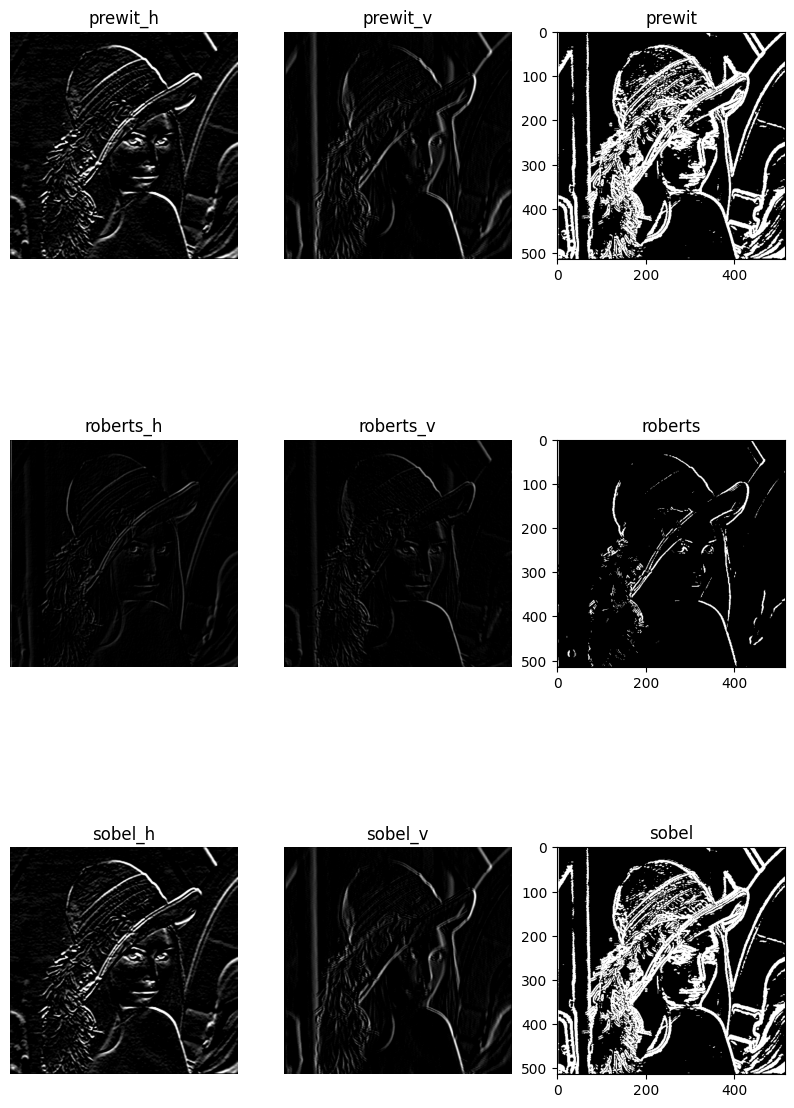

In [3]:
filters = ['prewit', 'roberts', 'sobel']
fig, axes = plt.subplots(len(filters), 3, figsize=(10, 15))

dsts = {}
finals = {}
th = 50
for i, filter in enumerate(filters):
    dirs = {}
    for j, direction in enumerate(['h', 'v']):
        dst = cv2.filter2D(src, -1, eval(filter)[direction])
        dirs[direction] = dst
        dst = np.clip(dst, 0, 255).astype(np.uint8)
        axes[i][j].imshow(dst, cmap='gray')
        axes[i][j].set_title(f'{filter}_{direction}')
        axes[i][j].axis('off')
    
    final = np.sqrt(dirs['h']**2 + dirs['v']**2)    
    final = np.where(final > th, 255, 0).astype(np.uint8)
    finals[filter] = final
    axes[i][2].imshow(final, cmap='gray')
    axes[i][2].set_title(f'{filter}')
    dsts[filter] = dirs

In [ ]:
def filter2d(src, mask):
    H, W = src.shape[:2]
    mask_size = mask.shape[0]
    pad = mask_size // 2
    dst = np.zeros_like(src).astype(np.float32)

    for h in range(pad , H - pad):
        for w in range(pad, W - pad):
            roi = src[h-pad : h-pad + mask_size, w-pad : w-pad + mask_size]
            dst[h, w] = np.sum(roi * mask)

    return dst

def edge_detect(src, mask, mask_size):
    mask_v = np.zeros((mask_size,mask_size) , dtype = np.float32)
    mask_h = np.zeros((mask_size, mask_size) , dtype = np.float32)
    if mask == "prewit":
        mask_v[:,0] = -1
        mask_v[:, mask_size -1] = 1

        mask_h[0] = -1
        mask_h[mask_size -1] = 1
    if mask == 'roberts':
        mask_v[0, 0] = -1 
        mask_v[mask_size//2 , mask_size // 2] = 1

        mask_h[0, mask_size-1] = -1
        mask_h[mask_size//2, mask_size//2] = 1
    if mask == 'sobel':
        mask_v[:,0] = -1
        mask_v[mask_size//2, 0] = -2
        mask_v[:, mask_size - 1] = 1
        mask_v[mask_size//2, mask_size - 1] = 2
 
        mask_h[0] = -1
        mask_h[0, mask_size//2] = -2
        mask_h[mask_size - 1] = 1
        mask_h[mask_size -1 , mask_size//2] = 2

    dst_v = filter2d(src, mask_v)
    dst_h = filter2d(src, mask_h)

    dst = np.sqrt((dst_v**2) + (dst_h **2))
    dst = np.clip(dst, 0, 255).astype(np.uint8)
    return dst

각 H, W 의 thr 정해서 할 수도 있음

Cv2.Canny 이용